# This notebook plots pre-computed spectra (and adds corresponding SSH map)

In [15]:
import netCDF4 as nc
import glob
import xarray as xr
import numpy as np
import datetime
from matplotlib import pyplot as plt, animation
import matplotlib.gridspec as gridspec

from scipy import signal
from scipy.interpolate import RegularGridInterpolator

import os
import sys as sys
sys.path.append('../src/')
from  spectral_analysis_functions import *


import swot_swell_utils as swell
from  lib_filters_obp import *
from wave_physics_functions import wavespec_Efth_to_Ekxky
import cmocean
import cmocean.cm as cmo
import matplotlib.colors as mcolors

from ipywidgets import interact, IntSlider, FloatRangeSlider,  FloatSlider, ToggleButtons
from ipywidgets import interactive_output, GridBox, Layout
from IPython.display import display
from ipywidgets import VBox


lightcmap = cmocean.tools.lighten(cmo.ice, 1)
lightcmap2 = cmocean.tools.lighten(cmo.ice_r, 1)


In [16]:
# Defines file names to be used and Load from NetCDF
mss_file='../data/mss/pass28_55S_mss.nc'
addj=0

# Below : example of cases used for the 2026 paper:
#"Noise or signal? Surface gravity waves in SWOT sea1 level measurements at wavelengths under 10 km"
# note that here the spectra plots includes the PTR correction.

#case a
ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_570_028_20230703T060212_20230703T065318_PGD0_01.nc" 
spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_570_028_20230703T060212_20230703T065318_v2.1_beta.nc' 
index0=812;thr_0=35;side0=4;addj=42;knmin=0.0005;knmax=2;res='res3'

#case b
ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_570_028_20230703T060212_20230703T065318_PGD0_01.nc" 
spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_570_028_20230703T060212_20230703T065318_v2.1_beta.nc' 
index0=792;thr_0=35;side0=4;addj=42;knmin=0.0005;knmax=2;res='res3'


#case c
#ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_540_028_20230603T104315_20230603T113421_PGD0_01.nc" 
# res 5 (20 km tiles) 
#spectra_file='../data/SPECTRA_res5/SWOT_L2_LR_WIND_WAVE_540_028_20230603T104315_20230603T113421_v2.1_beta.nc' 
#index0=398;thr_0=25;side0=0;addj=0;knmin=0.00015;knmax=0.0006;res='res5'
# res 3 (5 km tiles) 
#spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_540_028_20230603T104315_20230603T113421_v2.1_beta.nc' 
#index0=800;thr_0=25;side0=4;addj=42;knmin=0.0005;knmax=2;res='res3'

#case d
#ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_534_028_20230528T113929_20230528T123034_PGD0_01.nc" 
#spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_534_028_20230528T113929_20230528T123034_v2.1_beta.nc' 
#index0=807;thr_0=35;side0=1;addj=42;knmin=0.0005;knmax=2;res='res3'

#case f
#ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_534_028_20230528T113929_20230528T123034_PGD0_01.nc" 
#spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_564_028_20230627T065825_20230627T074930_v2.1_beta.nc'
#index0=807;thr_0=35;side0=1;addj=42;knmin=0.0005;knmax=2;res='res3'

#case g
spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_009_024_20240104T231743_20240105T000910_v2.1_beta.nc' 
ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_009_024_20240104T231743_20240105T000910_PGD0_02.nc" 
index0=236;thr_0=35;side0=4;addj=42;knmin=0.0005;knmax=2;res='res3'

#case h
#spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_009_052_20240105T231814_20240106T000941_v2.1_beta.nc' 
#ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_009_052_20240105T231814_20240106T000941_PGD0_02.nc" 
#index0=236;thr_0=40;side0=1;addj=42;knmin=0.0005;knmax=2;res='res3'

#case i
#spectra_file='../data/SPECTRA_res3/SWOT_L2_LR_WIND_WAVE_009_082_20240107T010230_20240107T015306_v2.1_beta.nc' 
#ssh_file = "../data/L2_LR_version_D/SWOT_L2_LR_SSH_Unsmoothed_009_082_20240107T010230_20240107T015306_PGD0_02.nc" 
#index0=221;thr_0=30;side0=1;addj=42;knmin=0.0005;knmax=2;res='res3'

ds_seg=xr.open_dataset(spectra_file)

n_strip = ds_seg.sizes['n_cross']
n_seg   = ds_seg.sizes['n_along']
nfy= ds_seg.sizes['nfy']
nfx= ds_seg.sizes['nfx']



In [25]:
def plot_spectrum(i, s,threshold):
    index_1d = i  + s*n_strip
    timec=ds_seg["time"][index_1d].values
    E = ds_seg["Efxfy_SWOT"][index_1d].values
    if res=='res3':
       E=(E+ds_seg["Efxfy_SWOT"][index_1d+6].values+ds_seg["Efxfy_SWOT"][index_1d-6].values)/3.
    
    kx2s = ds_seg["fx2D"].values
    ky2s = ds_seg["fy2D"].values
    dkx=kx2s[0,1]-kx2s[0,0]
    dky=ky2s[1,0]-ky2s[0,0]
    lo2=ds_seg["longitude"][index_1d].values
    la2=ds_seg["latitude"][index_1d].values
    angt=ds_seg["track_angle"][index_1d].values
    kn=np.sqrt(kx2s**2+ky2s**2) 
    bmask=np.where(kn > knmin,1,0)*np.where(kn < knmax,1,0)*np.where(kx2s < 0.0,1,0)*np.where(E >=10**(threshold/10),1,0)

    # defines mask for background noise 
    nmask=np.where(kn > knmin,1,0)*np.where(kn < knmax,1,0)
    mask = nmask > 0.5 
    En=np.nanmedian(E[mask])
    
    # Compute median noise for each ky2s (row-wise)
    #En_medians = np.nanmedian(E, axis=1)  # shape: (n_ky2s,)

    # Reshape and broadcast to match E's shape
    #En = np.broadcast_to(En_medians[:, np.newaxis], E.shape)

    Hs,Lmm1,LE,Lmp1,dm,sigth,Q18=swell.SWOTspec_to_HsLm(E-En,kx2s,ky2s,bmask,E*0+1,angt,doublesided=1,kmin=1E-4)
    print('lon,lat,angt,Hs,dm,LE,sigth:',lo2,la2,angt,Hs,dm,LE,sigth)
    
    times=str(timec)[0:4]+str(timec)[5:7]

  
    fig = plt.figure(figsize=(13, 8))
    gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[20, 1],   # small row for colorbars
    width_ratios=[1,   1],
    hspace=0.35,wspace=0.12)

    axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    ]

    cax0 = fig.add_subplot(gs[1, 0])
    cax1 = fig.add_subplot(gs[1, 1])
    # gs[1,2] intentionally unused

    fs1 = 20
    # ==========================================================
    # 1️⃣ --- LOAD SSH FILE (per strip) ---
    # ==========================================================
    if os.path.exists(ssh_file):
      if  i < n_strip//2 :
        ddl = xr.open_dataset(ssh_file, group='left') 
        side=0
      else: 
        ddl = xr.open_dataset(ssh_file, group='right') 
        side=1
      print('side:',side)
      SWOTvar='ssh'   # change this if you want to plot other variables ...
      if SWOTvar == "ssh" :
         L2_variable='ssh_karin_2'
         labelSWOT='ssh (m)'
         cmapSWOT=lightcmap
      if SWOTvar == "sigma0" :
         L2_variable="sig0_karin_2"
         labelSWOT='sigma0 (dB)'
         cmapSWOT='viridis'
      if SWOTvar == "uncertainty" :
         L2_variable="uncertainty"
         labelSWOT='uncertainty (dB)'
      if SWOTvar == "swh" :
         L2_variable="ssh_karin_2"

      lat = ddl.latitude.values
      lon = ddl.longitude.values

    # ==========================================================
    # 2️⃣ --- GET BOX INDICES (from ds_seg) ---
    # ==========================================================
      j1 = int(ds_seg["boxindices"][index_1d, 0].values)-addj
      j2 = int(ds_seg["boxindices"][index_1d, 1].values)+addj
      i1 = 39 #int(ds_seg["boxindices"][index_1d, 2].values)
      i2 = 199 #int(ds_seg["boxindices"][index_1d, 3].values)
      if i < n_strip//2  :
        side=0
        ix = -240-18+i1
        sflip=1
        dataSWOT0 = np.flip(ddl[L2_variable], axis=1)[j1:j2, i1:i2] 
        latSWOT = np.flip(lat, axis=1)[j1:j2, i1:i2] 
        lonSWOT = np.flip(lon, axis=1)[j1:j2, i1:i2] 
      else: 
        side=1
        ix = i1+19
        sflip=0
        dataSWOT0 = ddl[L2_variable][j1:j2, i1:i2] 
        latSWOT = lat[j1:j2, i1:i2] 
        lonSWOT = lon[j1:j2, i1:i2] 

    #dataSWOT,ssha_interp = correct_ssha_with_swot_mean(
    #    ncfile_path=mss_file,
    #    lat_2d=latSWOT,lon_2d=lonSWOT,ssha_2d=dataSWOT0.values,side=side,
    #    method='linear')
      dataSWOT=dataSWOT0.values    
    # ==========================================================
    # 3️⃣ --- BUILD SSH PANEL ---
    # ==========================================================
      dx, dy, indxc, ISHIFT, *_ = swell.spec_settings_for_L3(1, 'alpha')

      print('ind:',i,s,index_1d,'##',i1,i2,j1,j2,'##',indxc,ix,np.shape(ddl[L2_variable]))
      latmean=0.5*(lat[j2, i2 ]+ lat[j1, i1 ])
      lonmean=0.5*(lon[j2, i2 ]+ lon[j1, i1 ])

      X= (np.arange(dataSWOT.shape[1]) + ix) * dx / 1000
      Y= (np.arange(dataSWOT.shape[0]) - j1) * dy / 1000
      Y=Y-Y[0]

      print('lon,lat:',lo2,la2,'##',lonmean,latmean,'##',X[0],X[-1])

      detrenda = detrend_2d_quadratic(dataSWOT)
      amax = np.nanmax(detrenda)
      amin = np.nanmin(detrenda)

      amin=-0.28;amax=0.28 # forced range for figure 
    
      im0 = axs[0].pcolormesh(X, Y, detrenda,cmap=cmapSWOT,vmin=amin, vmax=amax,rasterized=True )
      fig.colorbar(im0, cax=cax0,orientation='horizontal',label=labelSWOT)
      midx=np.mean(X)
      midy=np.mean(Y)
      swell.arrows_on_spectrum(axs[0],0,side,angt,color='k',arx0=midx,ary0=midy,arxd=5,aryd=5,arwid=2)

      axs[0].set_xlabel('cross-track (km)', fontsize=fs1)
      axs[0].set_ylabel('along-track (km)', fontsize=fs1)
      axs[0].set_title('lon: '+f"{lonmean:.2f}"+'°'+'lat: '+f"{latmean:.2f}"+'°')
    else: 
      print('file:',ssh_file,' is not avaiable. Panel will be left empty.')



    # ==========================================================
    # 4️⃣ --- SPECTRUM PANEL ---
    # ==========================================================
    im1 = axs[1].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=0, vmax=50),rasterized=True, cmap='viridis')
    vertices=swell.SWOTspec_mask_polygon(bmask) 
    swell.draw_mask(axs[1],kx2s,dkx,ky2s,dky,vertices,color='w',lw=3)

    kpmax=0.5
    #axs[1].set_xlim([-kpmax,kpmax])
    #axs[1].set_ylim([-kpmax,kpmax])
    fig.colorbar(im1, cax=cax1,
             orientation='horizontal',
             label='dB re 1 m$^4$')

    axs[1].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)
    parts = ssh_file.split('_')
    axs[1].set_title(parts[-6]+'_'+parts[-5]+'_'+parts[-4])


    plt.savefig('test_spec.pdf')

strip_slider = IntSlider(
    min=0, max=n_strip-1, step=1,
    value=side0, description="X-track index"
)
seg_slider = IntSlider(
    min=0, max=n_seg-1, step=1,
    value=index0, description="along-track index"
)
thr_slider = FloatSlider(
    min=10, max=40, step=1,
    value=thr_0, description="PSD threshold (dB)"
)
beta_slider = FloatSlider(
    min=0, max=0.07, step=0.05,
    value=0.01, description="beta"
)



In [26]:
slider_grid = VBox([
    strip_slider,
    seg_slider,
    thr_slider
])

out = interactive_output(
    plot_spectrum,
    {
        "i": strip_slider,
        "s": seg_slider,
        "threshold": thr_slider,
    },
)


display(slider_grid, out)

Output()

In [19]:
# Now tests the cross-track position of "250 m" pixels... (this works with case b of Ardhuin et al. 2026 ) 

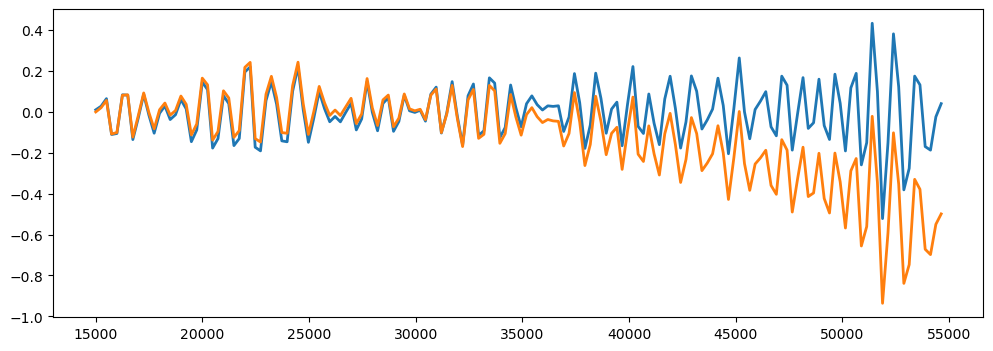

In [20]:
i=4;s=237
index_1d = i  + s*n_strip
if  i < n_strip//2 :
        ddl = xr.open_dataset(ssh_file, group='left') 
        side=0
else: 
        ddl = xr.open_dataset(ssh_file, group='right') 
        side=1
SWOTvar='ssh'
if SWOTvar == "ssh" :
         L2_variable='ssh_karin_2'
         labelSWOT='ssh (m)'
         cmapSWOT=lightcmap
if SWOTvar == "sigma0" :
         L2_variable="sig0_karin_2"
         labelSWOT='sigma0 (dB)'
         cmapSWOT='viridis'
if SWOTvar == "uncertainty" :
         L2_variable="uncertainty"
         labelSWOT='uncertainty (dB)'
if SWOTvar == "swh" :
         L2_variable="ssh_karin_2"

lat = ddl.latitude.values
lon = ddl.longitude.values

j1 = int(ds_seg["boxindices"][index_1d, 0].values)-addj
j2 = int(ds_seg["boxindices"][index_1d, 1].values)+addj
i1 = 39 #int(ds_seg["boxindices"][index_1d, 2].values)
i2 = 199 #int(ds_seg["boxindices"][index_1d, 3].values)
if i < n_strip//2  :
        side=0
        ix = -240-18+i1
        sflip=1
        dataSWOT = np.flip(ddl[L2_variable], axis=1)[j1:j2, i1:i2] 
        latSWOT = np.flip(lat, axis=1)[j1:j2, i1:i2] 
        lonSWOT = np.flip(lon, axis=1)[j1:j2, i1:i2] 
else: 
        side=1
        ix = i1+19
        sflip=0
        dataSWOT = ddl[L2_variable][j1:j2, i1:i2] 
        latSWOT = lat[j1:j2, i1:i2] 
        lonSWOT = lon[j1:j2, i1:i2] 

iy=80
lon1D=lonSWOT[iy,:]
lat1D=latSWOT[iy,:]
lo1=lon1D[0]
la1=lat1D[0]
RE=2E7/np.pi
nx=len(lon1D)
d1D=np.empty(nx)
d1D2=np.empty(nx)
for ix in range(nx):
    alpha,beta=swell.dist_sphere(lo1,lon1D[ix],la1,lat1D[ix])
    d1D[ix]=RE*alpha+15000
    d1D2[ix]=((RE*alpha)-249.3*ix)*d1D[ix]/839E3
from scipy.signal import detrend
ssh1D = detrend(dataSWOT[iy,:])
plt.figure(figsize=(12,4))

plt.plot(d1D,ssh1D,lw=2, label=r'$z(x)$')
plt.plot(d1D,d1D2,lw=2, label=r'$(x-x_0) tan(\theta)$')
